# Machine Learning Basic Template

End-to-end starter notebook: import → load → EDA → feature engineering → feature selection → split → scaling → modeling (regression & classification) → evaluation.

Replace `df`, `target`, and column lists with your actual dataset details.

## 1. Import Libraries

In [90]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler,
    LabelEncoder, OneHotEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load Dataset

In [91]:
# Load your dataset (CSV / Excel / SQL etc.)
df = pd.read_csv(r'C:\AHAMMED\BIA_DATA_SCIENCE\FIRST_PROJECT\MACHINE_LEARNING\DATASET\Housing.csv')

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 3. Exploratory Data Analysis (EDA)

Basic structure, types, summary stats, and missing values before any deeper analysis.

In [92]:
print("Shape:", df.shape)
df.info()

Shape: (545, 13)
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [93]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,545.0,NaN,NaN,NaN,4766729.247706,1870439.615657,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,NaN,NaN,NaN,5150.541284,2170.141023,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,NaN,NaN,NaN,2.965138,0.738064,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,NaN,NaN,NaN,1.286239,0.50247,1.0,1.0,1.0,2.0,4.0
stories,545.0,NaN,NaN,NaN,1.805505,0.867492,1.0,1.0,2.0,2.0,4.0
mainroad,545,2,yes,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
guestroom,545,2,no,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basement,545,2,no,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotwaterheating,545,2,no,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airconditioning,545,2,no,373,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
# Missing values overview
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
price,0,0.0
area,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
stories,0,0.0
mainroad,0,0.0
guestroom,0,0.0
basement,0,0.0
hotwaterheating,0,0.0
airconditioning,0,0.0


In [95]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### 3.1 Univariate Analysis

Distribution of each variable on its own — histograms for numeric columns, count plots for categorical columns.

In [96]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


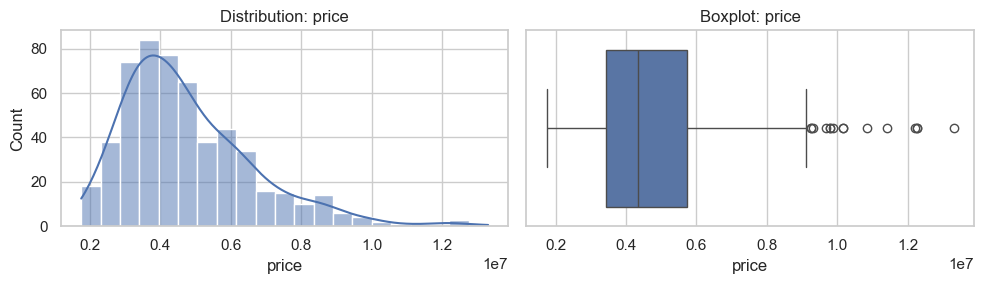

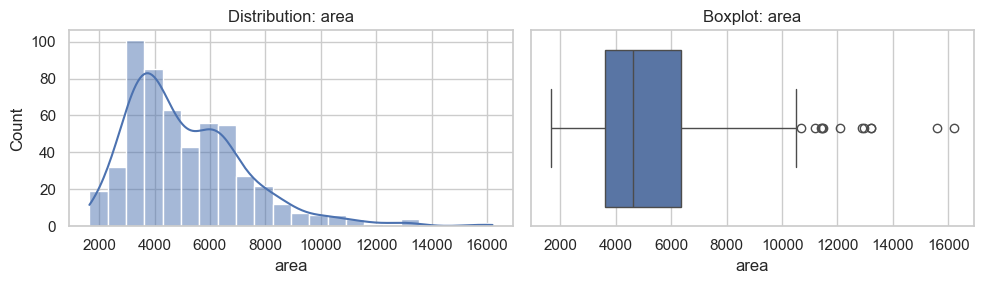

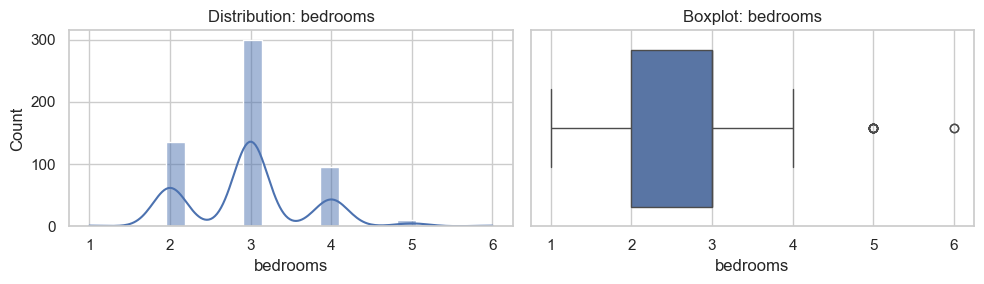

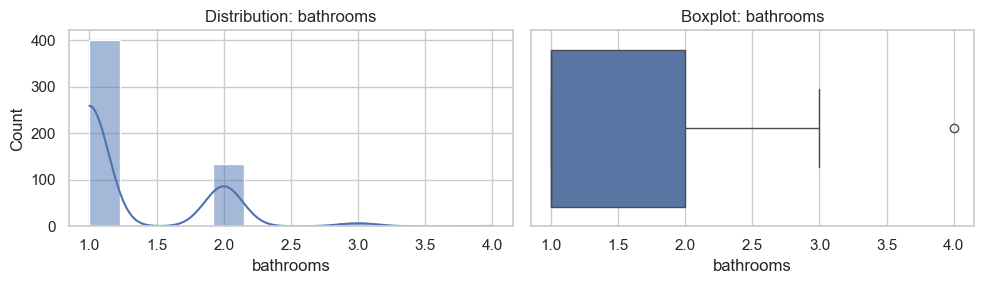

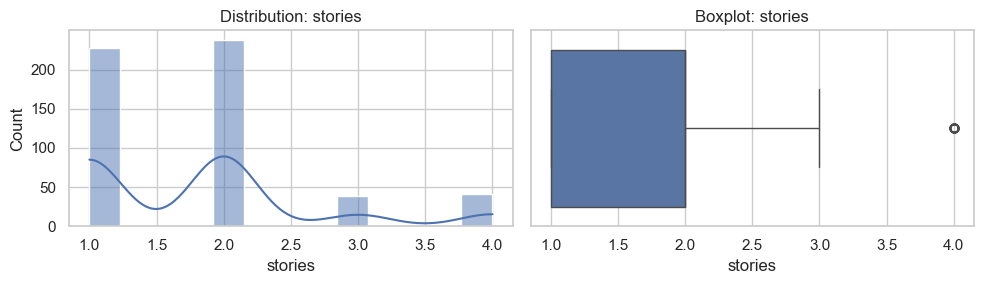

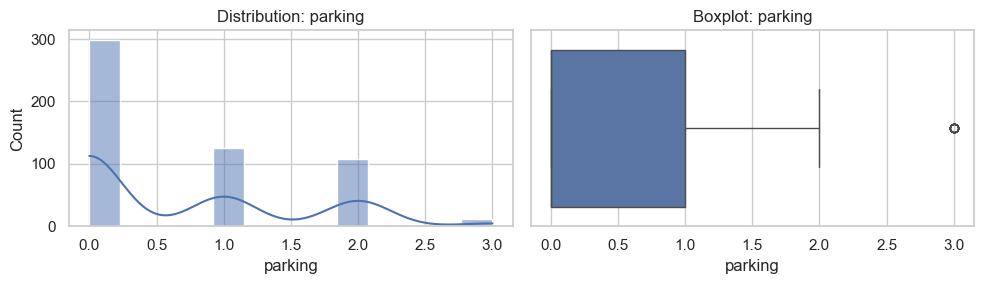

In [97]:
# Numeric: histograms + boxplots
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution: {col}")
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

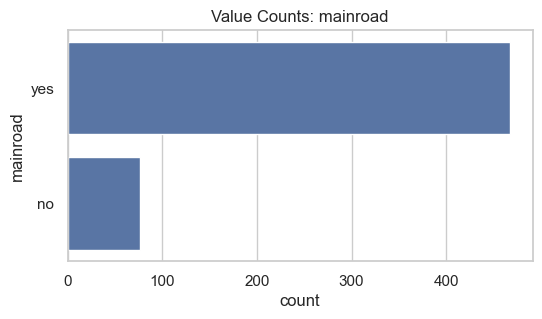

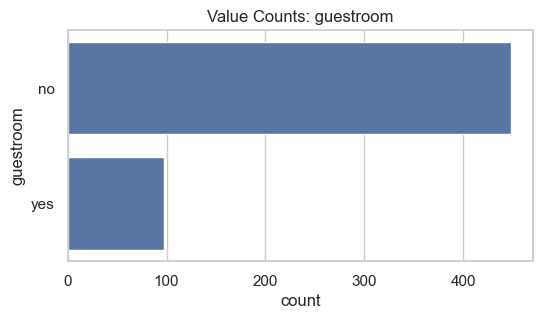

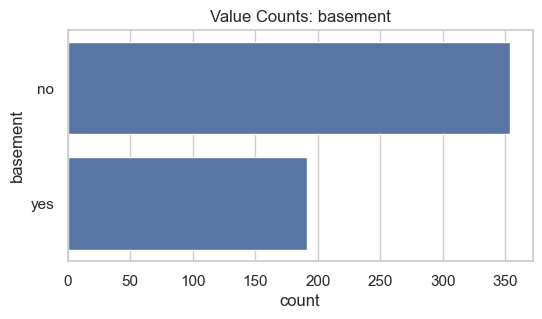

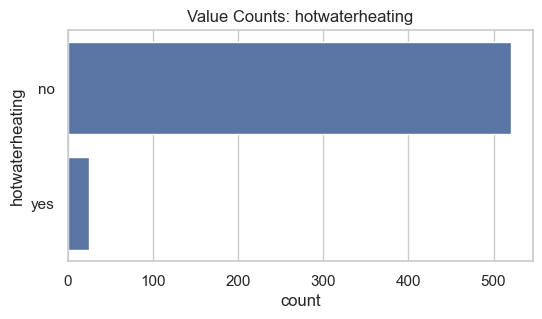

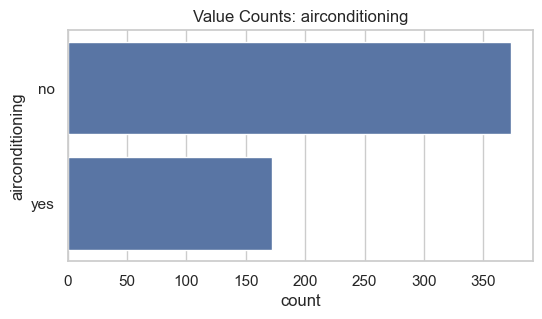

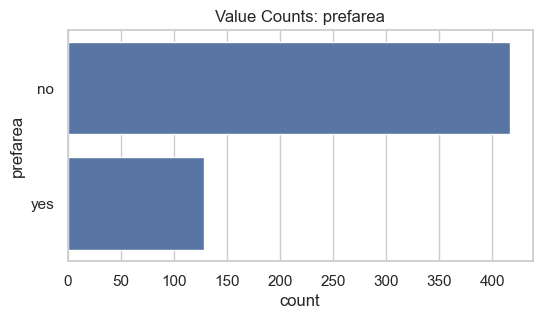

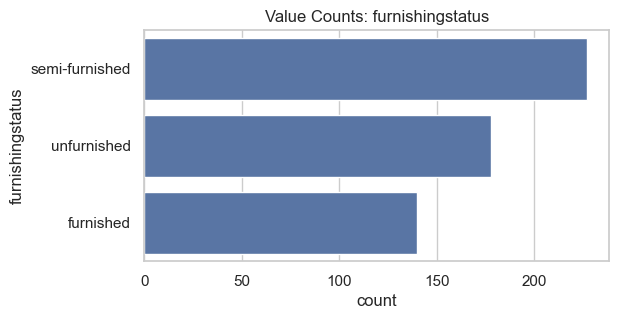

In [98]:
# Categorical: count plots
for col in cat_cols:
    plt.figure(figsize=(6, 3))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Value Counts: {col}")
    plt.show()

### 3.2 Bivariate Analysis

Relationship between each feature and the target, plus pairwise relationships among numeric features.

In [99]:
target = "target_column"  # set your target column name

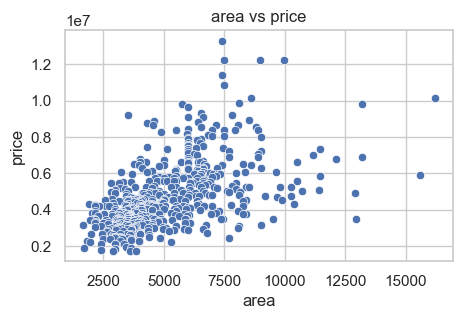

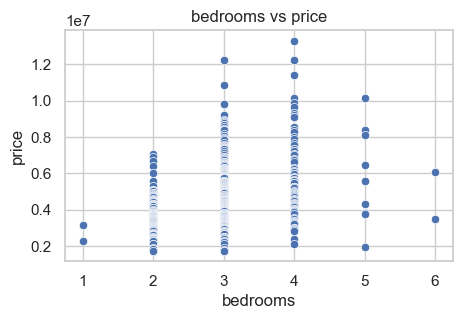

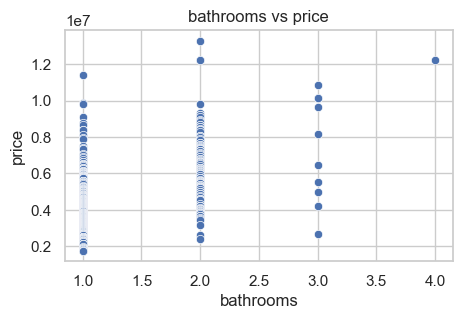

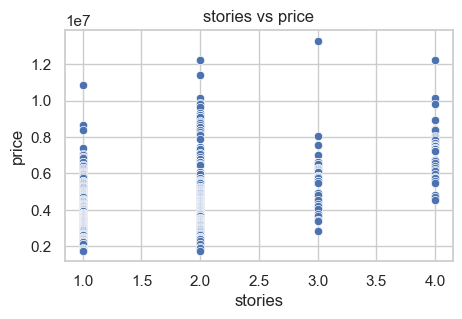

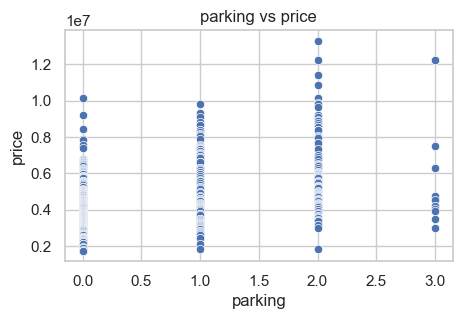

In [100]:
# Numeric feature vs numeric/continuous target
target = "price"

for col in num_cols:
    if col != target:
        plt.figure(figsize=(5, 3))
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f"{col} vs {target}")
        plt.show()

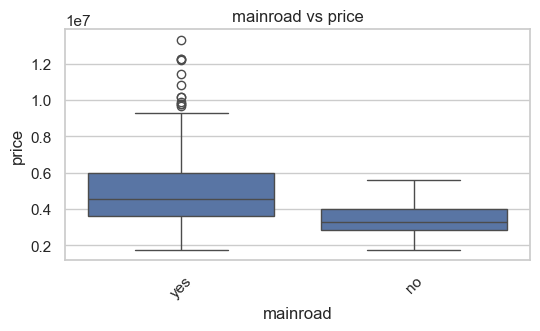

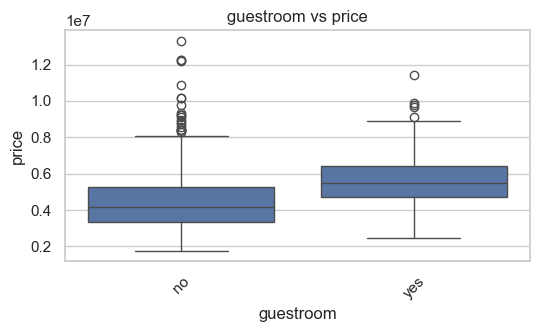

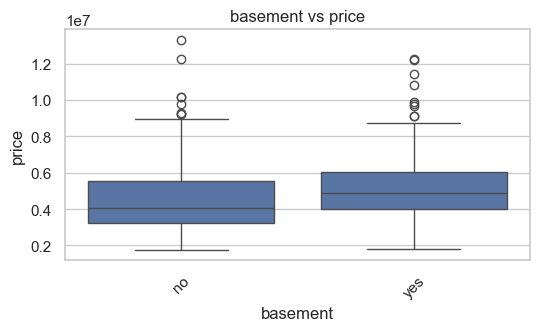

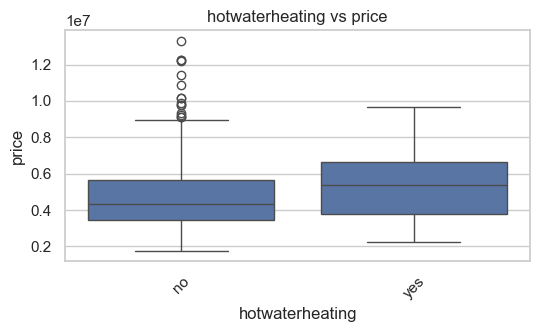

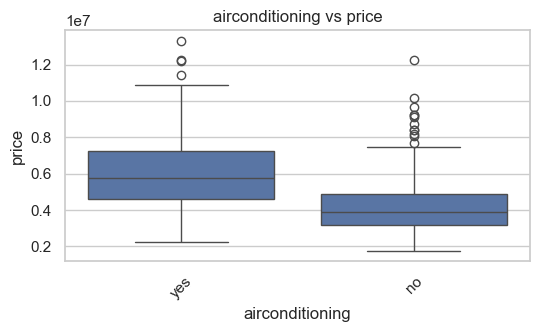

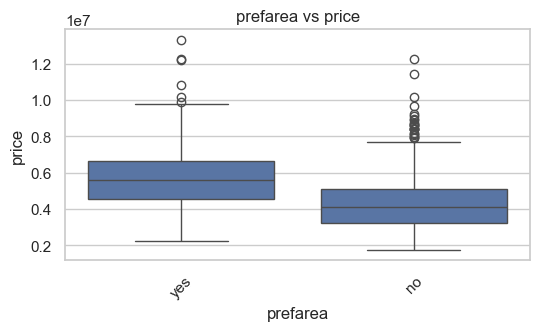

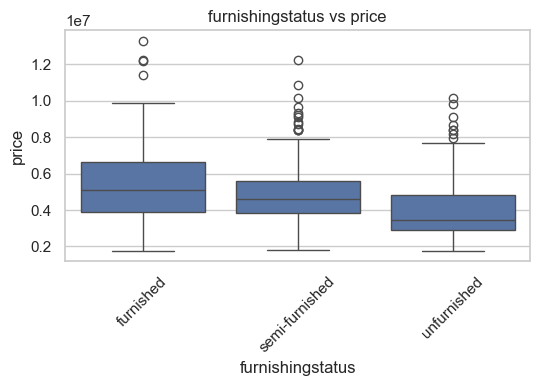

In [101]:
# Categorical feature vs target (boxplot, useful for regression target)
for col in cat_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col], y=df[target])
    plt.title(f"{col} vs {target}")
    plt.xticks(rotation=45)
    plt.show()

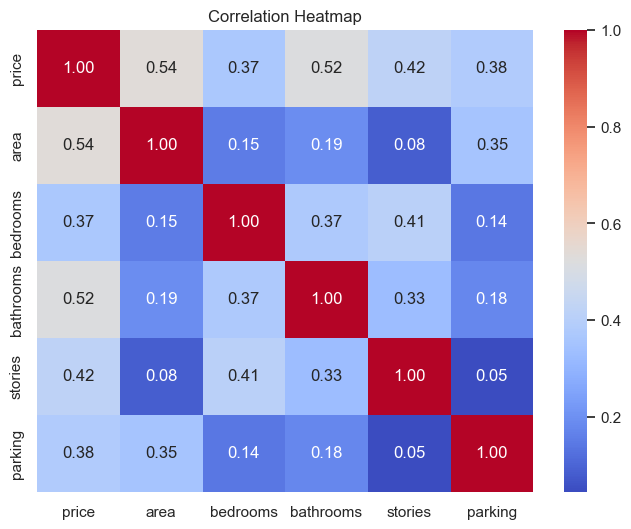

In [102]:
# Correlation heatmap (numeric features)
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

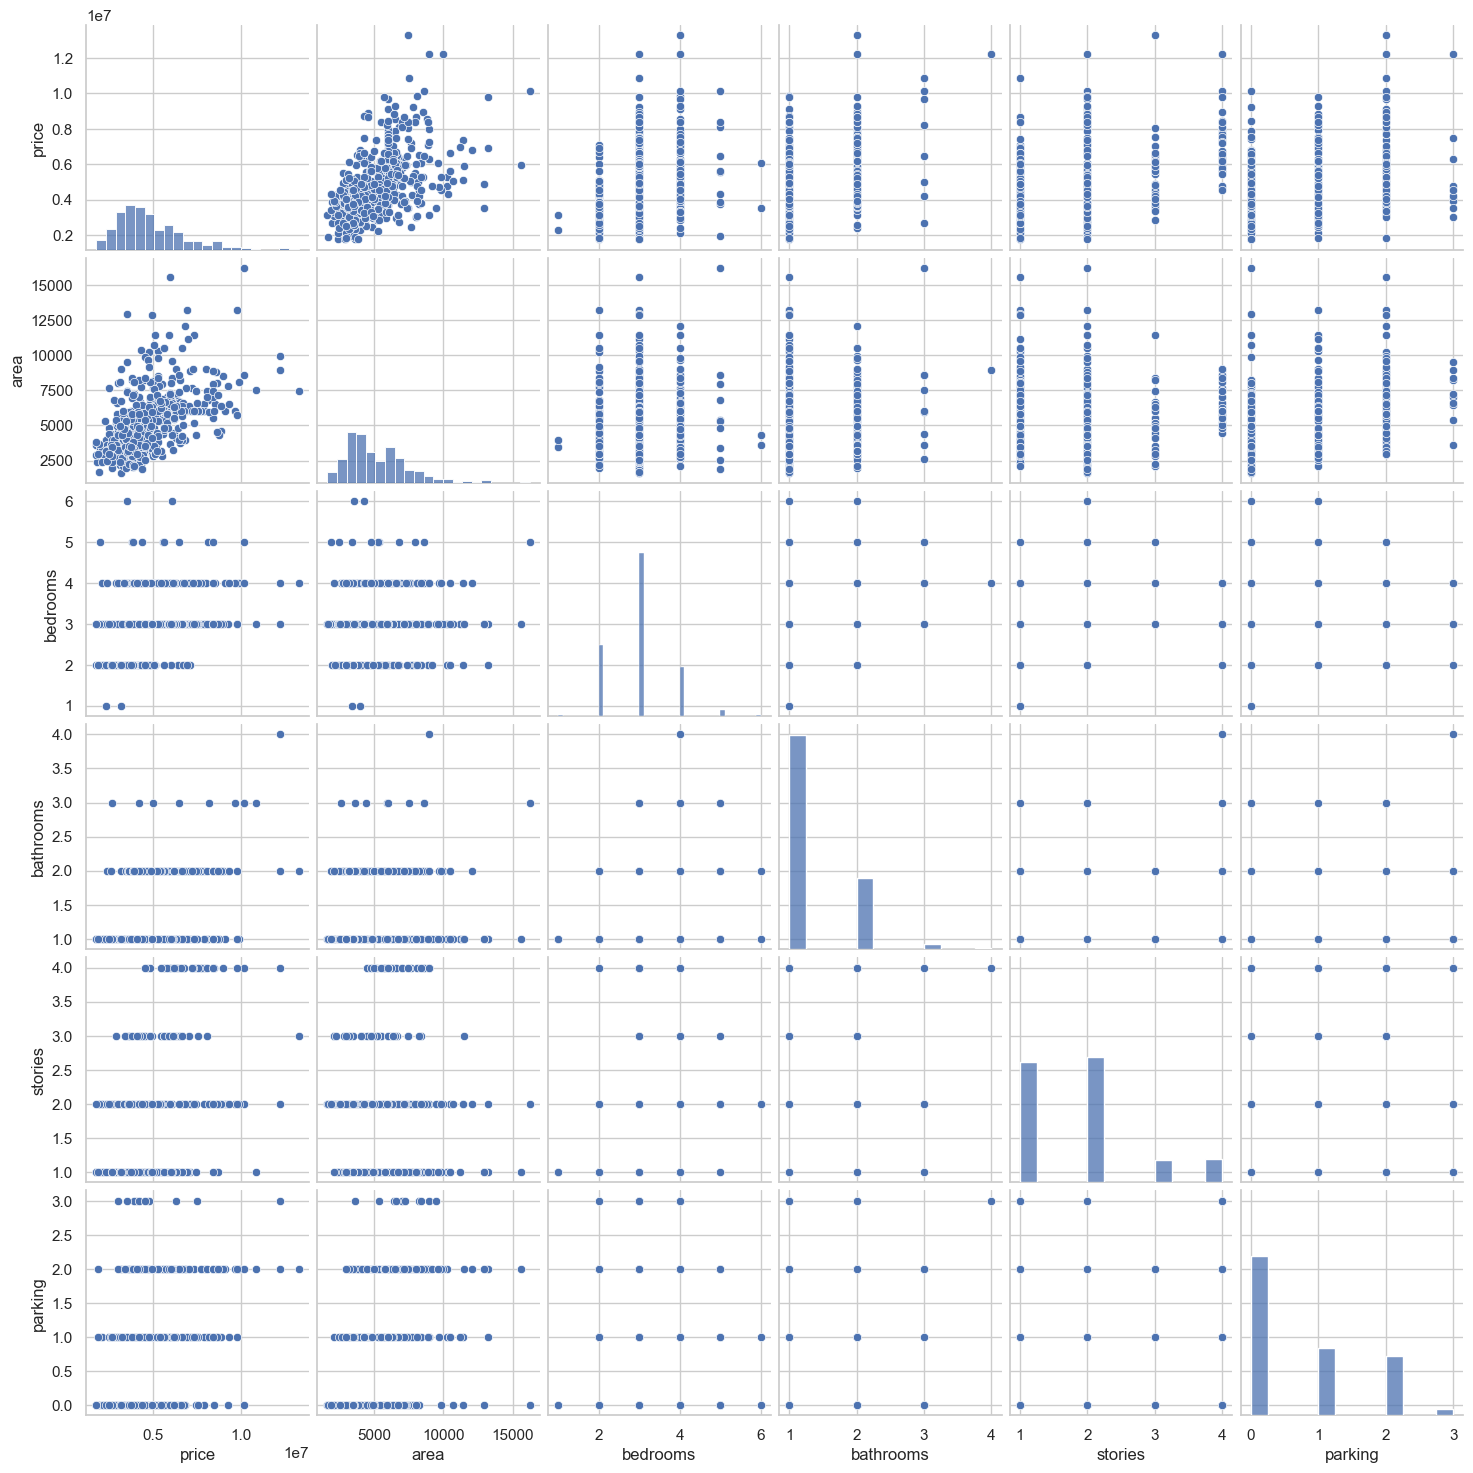

In [103]:
# Pairplot for a quick multi-variable view (sample if dataset is large)
sns.pairplot(df[num_cols].sample(min(500, len(df))))
plt.show()

## 4. Feature Engineering

### 4.1 Missing Value Treatment

Common strategies: drop, mean/median (numeric), mode (categorical), or model-based imputation.

In [104]:
# Numeric: median imputation
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical: mode imputation
cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# Alternative: drop rows/columns with too many missing values
# df = df.dropna(thresh=len(df) * 0.5, axis=1)   # drop columns with >50% missing
# df = df.dropna()                                # drop remaining rows with missing values

df.isnull().sum().sum()  # should be 0 after imputation

np.int64(0)

### 4.2 Outlier Treatment

IQR-based detection and capping (winsorizing). Adjust the multiplier as needed.

In [105]:
def cap_outliers_iqr(data, col, factor=1.5):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    data[col] = np.clip(data[col], lower, upper)
    return data

for col in num_cols:
    if col != target:
        df = cap_outliers_iqr(df, col)

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.102250e+03,2.005804e+03,1650.0,3600.0,4600.0,6360.0,10500.0
bedrooms,545.0,2.950459e+00,6.975039e-01,1.0,2.0,3.0,3.0,4.5
bathrooms,545.0,1.285321e+00,4.979417e-01,1.0,1.0,1.0,2.0,3.5
stories,545.0,1.767890e+00,7.775434e-01,1.0,1.0,2.0,2.0,3.5
parking,545.0,6.825688e-01,8.347732e-01,0.0,0.0,0.0,1.0,2.5


### 4.3 Encoding Categorical Variables

#### Simple / Label Mapping

Use when a column has an obvious manual mapping (e.g. binary Yes/No → 1/0).

In [106]:
# Example: manual map for a binary column
# df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

# Generic LabelEncoder (good for binary / target encoding, not ideal for nominal multi-class features)
le = LabelEncoder()
# df["binary_col"] = le.fit_transform(df["binary_col"])

#### One-Hot Encoding

Use for nominal categorical features with no inherent order.

In [107]:
# Encode binary categorical columns
binary_cols = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

# One-Hot Encode the remaining nominal column
df = pd.get_dummies(
    df,
    columns=["furnishingstatus"],
    drop_first=True
)

#### Ordinal Encoding

Use for categorical features with a natural order (e.g. Low < Medium < High).

In [108]:
ordinal_cols = []  # e.g. ["education_level"]
ordinal_categories = []  # e.g. [["High School", "Bachelors", "Masters", "PhD"]]

# oe = OrdinalEncoder(categories=ordinal_categories)
# df[ordinal_cols] = oe.fit_transform(df[ordinal_cols])

## 5. Feature Selection

### 5.1 Correlation

Drop one of each pair of highly correlated features (multicollinearity reduction).

In [109]:
corr_matrix = df.select_dtypes(include=np.number).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.85
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
print("Highly correlated columns to consider dropping:", to_drop)

# df = df.drop(columns=to_drop)

Highly correlated columns to consider dropping: []


### 5.2 Variance Inflation Factor (VIF)

VIF quantifies multicollinearity per feature. VIF > 5 (or 10) typically signals a problematic feature.

In [110]:
def calculate_vif(data, features):
    X = data[features].assign(intercept=1)
    vif_df = pd.DataFrame()
    vif_df["feature"] = features
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(features))]
    return vif_df.sort_values("VIF", ascending=False)

vif_features = [c for c in df.select_dtypes(include=np.number).columns if c != target]
vif_result = calculate_vif(df, vif_features)
vif_result

,feature,VIF
3,stories,1.513472
1,bedrooms,1.441784
0,area,1.369455
6,basement,1.312316
2,bathrooms,1.273420
9,parking,1.219068
5,guestroom,1.213975
8,airconditioning,1.197822
4,mainroad,1.170054
10,prefarea,1.154321


## 6. Train-Test Split

In [111]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (436, 13) Test shape: (109, 13)


## 7. Feature Scaling

### 7.1 Normalization (MinMaxScaler)

Scales features to a fixed range [0, 1]. Good when data isn't normally distributed or for distance-based models.

In [112]:
target = "price"

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

### 7.2 Standardization (StandardScaler)

Centers data to mean 0, std 1. Preferred for linear models, SVM, PCA, etc.

In [113]:
std_scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = std_scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = std_scaler.transform(X_test[num_cols])

## 8. Model Building — Regression

Use when the target is continuous. Use `X_train_scaled` / `X_test_scaled` (or `_norm`) as appropriate for the model.

In [114]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lin = lin_reg.predict(X_test_scaled)

In [115]:
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_reg.predict(X_test_scaled)

In [116]:
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_reg.predict(X_test_scaled)

In [117]:
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_train)  # tree-based models don't need scaling
y_pred_dt = dt_reg.predict(X_test)

In [118]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

### Regression Evaluation Metrics

In [119]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

def regression_summary(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("=" * 50)
    print(f"Model : {model_name}")
    print("=" * 50)
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    print()

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2
    }


reg_results = []

reg_results.append(regression_summary(y_test, y_pred_lin, "Linear Regression"))
reg_results.append(regression_summary(y_test, y_pred_ridge, "Ridge Regression"))
reg_results.append(regression_summary(y_test, y_pred_lasso, "Lasso Regression"))

results_df = pd.DataFrame(reg_results)

print("\nRegression Model Comparison")
display(results_df.sort_values(by="R² Score", ascending=False))

Model : Linear Regression
MAE  : 980346.82
MSE  : 1754676511779.81
RMSE : 1324642.03
R²   : 0.6529

Model : Ridge Regression
MAE  : 979771.17
MSE  : 1754715596728.96
RMSE : 1324656.78
R²   : 0.6528

Model : Lasso Regression
MAE  : 980346.77
MSE  : 1754676579939.77
RMSE : 1324642.06
R²   : 0.6529


Regression Model Comparison


,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,980346.816875,1.754677e+12,1.324642e+06,0.652853
2,Lasso Regression,980346.772886,1.754677e+12,1.324642e+06,0.652853
1,Ridge Regression,979771.174828,1.754716e+12,1.324657e+06,0.652846


## 9. Model Building — Classification

Use when the target is categorical. Use `X_train_scaled` / `X_test_scaled` (or `_norm`) as appropriate for the model.

In [120]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

In [121]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dtc = dt_clf.predict(X_test)

In [122]:
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rfc = rf_clf.predict(X_test)
y_prob_rfc = rf_clf.predict_proba(X_test)[:, 1]

In [123]:
svm_clf = SVC(kernel="rbf", probability=True, random_state=42)
svm_clf.fit(X_train_scaled, y_train)
y_pred_svm = svm_clf.predict(X_test_scaled)

### Classification Evaluation Metrics

In [124]:
'''def classification_report_summary(y_true, y_pred, model_name="Model", y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"--- {model_name} ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")

    auc = None
    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob)
        print(f"ROC-AUC   : {auc:.4f}")

    print()
    return {"model": model_name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "ROC_AUC": auc}

clf_results = []
clf_results.append(classification_report_summary(y_test, y_pred_log, "Logistic Regression", y_prob_log))
clf_results.append(classification_report_summary(y_test, y_pred_dtc, "Decision Tree Classifier"))
clf_results.append(classification_report_summary(y_test, y_pred_rfc, "Random Forest Classifier", y_prob_rfc))
clf_results.append(classification_report_summary(y_test, y_pred_svm, "SVM Classifier"))

pd.DataFrame(clf_results).sort_values("F1", ascending=False)'''

'def classification_report_summary(y_true, y_pred, model_name="Model", y_prob=None):\n    acc = accuracy_score(y_true, y_pred)\n    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)\n    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)\n    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)\n    print(f"--- {model_name} ---")\n    print(f"Accuracy  : {acc:.4f}")\n    print(f"Precision : {prec:.4f}")\n    print(f"Recall    : {rec:.4f}")\n    print(f"F1-score  : {f1:.4f}")\n\n    auc = None\n    if y_prob is not None:\n        auc = roc_auc_score(y_true, y_prob)\n        print(f"ROC-AUC   : {auc:.4f}")\n\n    print()\n    return {"model": model_name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "ROC_AUC": auc}\n\nclf_results = []\nclf_results.append(classification_report_summary(y_test, y_pred_log, "Logistic Regression", y_prob_log))\nclf_results.append(classification_report_summary(y_test, y_pred_dtc, "Deci

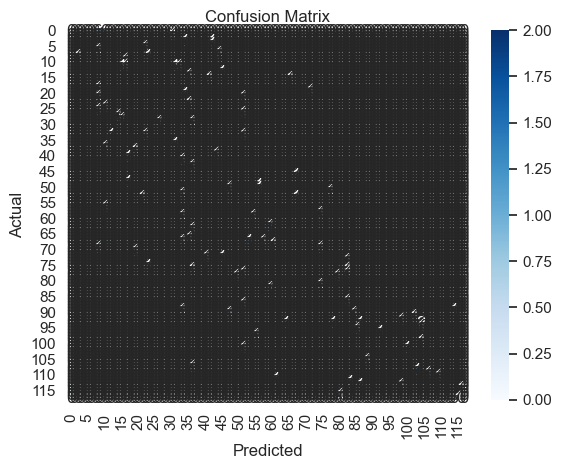

              precision    recall  f1-score   support

   1750000.0       0.00      0.00      0.00       1.0
   1820000.0       0.00      0.00      0.00       1.0
   1855000.0       0.00      0.00      0.00       0.0
   1890000.0       0.00      0.00      0.00       2.0
   2100000.0       0.00      0.00      0.00       1.0
   2233000.0       0.00      0.00      0.00       1.0
   2275000.0       0.00      0.00      0.00       1.0
   2380000.0       0.00      0.00      0.00       1.0
   2450000.0       0.00      0.00      0.00       2.0
   2520000.0       0.00      0.00      0.00       1.0
   2653000.0       0.00      0.00      0.00       0.0
   2660000.0       0.00      0.00      0.00       4.0
   2730000.0       0.00      0.00      0.00       0.0
   2800000.0       0.00      0.00      0.00       1.0
   2870000.0       0.00      0.00      0.00       1.0
   2940000.0       0.00      0.00      0.00       2.0
   2961000.0       0.00      0.00      0.00       0.0
   2975000.0       0.00    

In [125]:
# Confusion matrix (example: best/last model)
cm = confusion_matrix(y_test, y_pred_rfc)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_rfc))

## 10. Save Model (joblib)

Persist the trained model (and scaler, since predictions on new data must be scaled the same way) to disk for later reuse.

In [126]:
import joblib

# Save the trained Linear Regression model
joblib.dump(lin_reg, "linear_regression.joblib")

# Save the scaler used during preprocessing
joblib.dump(std_scaler, "scaler_regression.joblib")

print("Saved: linear_regression.joblib")
print("Saved: scaler_regression.joblib")

Saved: linear_regression.joblib
Saved: scaler_regression.joblib


In [127]:
# --- Save a classification model ---
joblib.dump(rf_clf, "rf_classifier.joblib")
joblib.dump(std_scaler, "scaler_classification.joblib")

print("Saved: rf_classifier.joblib, scaler_classification.joblib")

Saved: rf_classifier.joblib, scaler_classification.joblib


### Load Model (for reuse)

In [128]:
loaded_model = joblib.load("linear_regression.joblib")
loaded_scaler = joblib.load("scaler_regression.joblib")